<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/12_sensitivity_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB12 — Sensibilidade Compacta e Robustez das Escolhas

## 1. Papel deste notebook no pipeline

Este notebook dá continuidade às decisões metodológicas consolidadas no NB10 e avaliadas experimentalmente no NB11.

O NB10 selecionou cenários temporalmente defensáveis a partir de variações de granularidade, região BEFORE/AFTER, horizonte preditivo, persistência mínima e critério de limiar. O NB11 avaliou os cenários promovidos por meio de baselines temporais, modelos supervisionados tabulares, calibração inicial e lead time.

O NB12 tem papel diferente: ele não deve repetir o NB11, não deve reabrir grid search amplo e não deve comparar novamente famílias de modelos. Sua função é verificar se a escolha central do pipeline permanece razoavelmente estável diante de variações metodológicas moderadas, especialmente em relação a limiar, persistência mínima e referência histórica.

Assim, o NB12 é um notebook de sensibilidade compacta, não de otimização de desempenho.

## 2. Objetivo

Verificar se o cenário principal definido após NB10/NB11 permanece defensável quando comparado a cenários de sensibilidade, sem reabrir todo o espaço de 72 cenários avaliado no NB10.

De forma específica, este notebook busca:

1. carregar os cenários classificados no NB10;
2. identificar cenários de sensibilidade (`sensitivity_only`) e referências históricas (`historical_reference`);
3. executar somente o modelo vencedor do NB11 nos cenários de sensibilidade elegíveis;
4. não executar modelo sobre cenários `train_p99`, tratando-os apenas como severidade extrema descritiva;
5. manter `global_m2s` apenas como referência histórica;
6. comparar o desempenho de cenários `train_p95` com o cenário principal `train_m2s`;
7. avaliar se a cláusula de revisão metodológica é acionada;
8. produzir artefatos rastreáveis para NB14, NB15 e NB16.

## 3. Entradas esperadas

Este notebook consome artefatos do NB10 e do NB11.

### 3.1 Entradas do NB10

- `10_scenario_decisions.csv`
- `10_scenario_series_states.parquet`
- `10_scenario_episodes.parquet`
- `10_scenario_episode_summary.csv`, se disponível
- `10_scenario_label_impact.csv`, se disponível
- `10_scenario_thresholds_summary.csv`, se disponível
- `10_scenario_diagnostics_summary.json`, se disponível

Esses arquivos fornecem as decisões metodológicas, a série rotulada por cenário, os episódios críticos e os resumos descritivos usados para sensibilidade.

### 3.2 Entradas do NB11

- `11_winner_model.json`
- `11_nb11_summary.json`, se disponível
- `11_metrics_summary.csv`, se disponível

O arquivo `11_winner_model.json` define o modelo tabular vencedor que será usado no NB12.

## 4. Decisão herdada do NB11

O NB11 selecionou como referência principal:

| Item | Valor |
|---|---|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Feature set | `temporal_core` |
| Modelo | Regressão Logística |
| Nº de features | 14 |
| F1 médio TSCV | 0,577 |
| Recall médio TSCV | 0,833 |
| Precisão média TSCV | 0,482 |
| ROC-AUC médio TSCV | 0,647 |
| Average Precision média | 0,559 |

O NB12 não reestima a família de modelos. Ele reutiliza o vencedor do NB11 como modelo fixo para avaliar robustez sob cenários de sensibilidade.

## 5. Escopo definitivo do NB12

O escopo deste notebook é deliberadamente restrito.

| Elemento | Tratamento no NB12 |
|---|---|
| `train_m2s` | Referência principal herdada do NB10/NB11 |
| `train_p95` | Sensibilidade essencial |
| `P3` | Sensibilidade restritiva de persistência |
| `global_m2s` | Referência histórica do artigo |
| `train_p99` | Severidade extrema apenas descritiva |
| `sensitivity_only` | Cenários elegíveis para execução compacta do vencedor do NB11 |
| `advance_to_nb11` | Já avaliados no NB11; não precisam ser repetidos integralmente |
| `do_not_advance` | Não avaliados por modelo |

O NB12 não deve repetir Random Forest, HistGradientBoosting, múltiplos baselines ou comparações extensas. O único modelo supervisionado executado é o vencedor do NB11.

## 6. Critérios de inclusão e exclusão

### 6.1 Cenários executados com o modelo vencedor

São executados com o modelo vencedor do NB11 os cenários que atendem simultaneamente às seguintes condições:

1. foram classificados pelo NB10 como `sensitivity_only`;
2. não usam limiar `train_p99`;
3. não são apenas referência histórica `global_m2s`;
4. possuem base supervisionada reconstruível;
5. possuem as features necessárias ao modelo vencedor.

### 6.2 Cenários não executados

Não são executados:

- cenários `train_p99`, pois representam severidade extrema e devem ser tratados apenas com métricas descritivas;
- cenários `global_m2s` classificados como referência histórica;
- cenários `do_not_advance`;
- cenários já avaliados no NB11, exceto se forem usados apenas como referência comparativa.

## 7. Tratamento específico de `train_p95`

O `train_p95` é a sensibilidade essencial do NB12.

Ele deve responder se um limiar causal percentílico, mais sensível que `train_m2s`, produz desempenho supervisionado substancialmente melhor no mesmo modelo vencedor.

A cláusula de revisão metodológica é:

> Se o F1 médio no TimeSeriesSplit de um cenário `train_p95` comparável superar o F1 médio do cenário principal `train_m2s` por mais de 5 pontos percentuais, a escolha do cenário principal deve ser reavaliada. Caso contrário, `train_p95` permanece como sensibilidade, sem reabrir o pipeline principal.

O valor de referência do NB11 é o F1 médio TSCV do cenário principal:

$$
F1_{NB11} = 0{,}577
$$

Assim, a revisão metodológica é acionada somente se:

$$
F1_{train\_p95} > 0{,}627
$$

## 8. Tratamento específico de `P3`

A persistência mínima `P3` representa sensibilidade restritiva.

Ela exige episódios críticos com pelo menos 3 janelas consecutivas, tornando a definição de criticidade mais conservadora. O objetivo é verificar se a decisão central permanece coerente quando episódios de uma ou duas janelas são removidos.

A sensibilidade `P3` deve ser interpretada com cautela, pois tende a reduzir o número de episódios, diminuir a taxa positiva e alterar a natureza da tarefa supervisionada.

## 9. Tratamento específico de `global_m2s`

O limiar `global_m2s` deve permanecer como referência histórica do artigo.

Ele é útil para comparação retrospectiva com a linha original do pipeline, mas não deve ser usado como cenário causal principal, pois foi estimado com a série completa.

No NB12, `global_m2s` deve ser descrito, mas não deve deslocar o cenário principal `train_m2s`.

## 10. Tratamento específico de `train_p99`

O `train_p99` representa severidade extrema.

Por definição, esse limiar tende a selecionar poucos episódios, com maior intensidade e menor frequência. A especificação do NB12 define que `train_p99` deve ser tratado apenas com métricas descritivas herdadas do NB10, sem execução do modelo vencedor.

Portanto, o NB12 deve reportar para `train_p99`, quando disponível:

- quantidade de episódios;
- quantidade de janelas críticas;
- quantidade de linhas supervisionadas;
- taxa positiva;
- categoria de decisão do NB10;
- observação metodológica de severidade extrema.

## 11. Modelo executado

O único modelo supervisionado executado no NB12 é o vencedor do NB11.

Na execução atual do pipeline, o vencedor é:

| Item | Valor |
|---|---|
| Modelo | Regressão Logística |
| Feature set | `temporal_core` |
| Estratégia de desbalanceamento | `class_weight="balanced"` |
| Escalador | `StandardScaler` |
| Validação principal | `TimeSeriesSplit` |
| Nº de folds | 5 |
| Limiar inicial | 0,5 |

As features utilizadas são:

- `fail_rate`
- `n_events`
- `n_failed`
- `n_machines`
- `n_collections`
- `event_FAIL_count`
- `event_LOST_count`
- `lag_1`
- `lag_2`
- `lag_3`
- `rolling_mean_1h`
- `rolling_std_1h`
- `pct_change`
- `zscore_expanding`

## 12. Protocolo de validação

A validação principal permanece `TimeSeriesSplit`, com 5 partições temporais progressivas.

O corte fixo 80/20 é mantido apenas como análise complementar e para inspeção comparativa.

Não há validação cruzada aleatória comum, pois a ordem temporal deve ser preservada.

Escaladores, limiares auxiliares e parâmetros de modelos devem ser ajustados apenas no treino de cada fold, sem vazamento do teste.

## 13. Métricas

São calculadas as seguintes métricas:

- acurácia;
- precisão;
- recall;
- F1-score;
- ROC-AUC;
- Average Precision;
- Brier Score;
- matriz de confusão;
- falsos alertas por dia.

O F1 médio no TimeSeriesSplit é a métrica principal para a cláusula de revisão metodológica. Recall, precisão, Average Precision e ROC-AUC são usados como métricas auxiliares.

## 14. Artefatos produzidos

O NB12 produz:

- `12_sensitivity_metrics_tscv.csv`
- `12_sensitivity_metrics_fixed_split.csv`
- `12_sensitivity_summary.csv`
- `12_sensitivity_descriptive.csv`
- `12_train_p95_review.json`
- `12_scores_sensitivity_fixed.parquet`
- `12_nb12_summary.json`
- figuras comparativas de F1, recall, taxa positiva e deltas em relação ao NB11.

## 15. Critério de fechamento

O NB12 será considerado fechado se:

1. executar o modelo vencedor do NB11 apenas sobre cenários elegíveis de sensibilidade;
2. preservar `train_p99` apenas como descrição de severidade extrema;
3. manter `global_m2s` como referência histórica;
4. emitir decisão objetiva sobre reabrir ou não o cenário principal;
5. gerar artefatos rastreáveis para NB14, NB15 e NB16;
6. não reabrir grid search amplo nem repetir o NB11.

A conclusão esperada deve indicar se `W5_K24_H12_P1_TRAIN_M2S` permanece como cenário principal ou se algum cenário `train_p95` exige reavaliação metodológica.

NB12 iniciado em: 2026-05-24 05:22:07
Mounted at /content/drive
[BACKUP NB12] Nenhum artefato anterior encontrado para backup.
BASE_DIR    : /content/drive/MyDrive/Mestrado
REPORTS_DIR : /content/drive/MyDrive/Mestrado/04-reports
NB11_DIR    : /content/drive/MyDrive/Mestrado/04-reports
NB12_DIR    : /content/drive/MyDrive/Mestrado/04-reports
FIGURES_DIR : /content/drive/MyDrive/Mestrado/04-reports/figures_nb12
Entradas localizadas:
  10 decisions : /content/drive/MyDrive/Mestrado/04-reports/10_scenario_decisions.csv
  10 states    : /content/drive/MyDrive/Mestrado/04-reports/10_scenario_series_states.parquet
  10 episodes  : /content/drive/MyDrive/Mestrado/04-reports/10_scenario_episodes.parquet
  11 winner    : /content/drive/MyDrive/Mestrado/04-reports/11_winner_model.json
df_decisions: (72, 49)
df_states_all: (482220, 34)
df_episodes_all: (7524, 14)
winner: {'scenario_label': 'W5_K24_H12_P1_TRAIN_M2S', 'feature_set': 'temporal_core', 'model': 'logistic_regression', 'f1_tscv_mean': 0

,scenario_id,decision_category,W,K,H,P,threshold_kind
8,W5_K12_H6_P3_TRAIN_M2S,sensitivity_only,5,12,6,3,TRAIN_M2S
9,W5_K12_H6_P1_TRAIN_P95,sensitivity_only,5,12,6,1,TRAIN_P95
10,W5_K12_H6_P2_TRAIN_P95,sensitivity_only,5,12,6,2,TRAIN_P95
11,W5_K12_H6_P3_TRAIN_P95,sensitivity_only,5,12,6,3,TRAIN_P95
12,W5_K24_H12_P3_TRAIN_M2S,sensitivity_only,5,24,12,3,TRAIN_M2S
13,W5_K24_H12_P1_TRAIN_P95,sensitivity_only,5,24,12,1,TRAIN_P95
14,W5_K24_H12_P2_TRAIN_P95,sensitivity_only,5,24,12,2,TRAIN_P95
15,W5_K24_H12_P3_TRAIN_P95,sensitivity_only,5,24,12,3,TRAIN_P95
16,W5_K24_H6_P3_TRAIN_M2S,sensitivity_only,5,24,6,3,TRAIN_M2S
17,W5_K24_H6_P1_TRAIN_P95,sensitivity_only,5,24,6,1,TRAIN_P95



Avaliando cenário de sensibilidade: W5_K12_H6_P3_TRAIN_M2S
Linhas supervisionadas: 8488
Taxa positiva: 0.0218
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K12_H6_P1_TRAIN_P95
Linhas supervisionadas: 7007
Taxa positiva: 0.2791
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K12_H6_P2_TRAIN_P95
Linhas supervisionadas: 7962
Taxa positiva: 0.0706
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K12_H6_P3_TRAIN_P95
Linhas supervisionadas: 8426
Taxa positiva: 0.0274
window_minutes: 5
h_windows: 6

Avaliando cenário de sensibilidade: W5_K24_H12_P3_TRAIN_M2S
Linhas supervisionadas: 8279
Taxa positiva: 0.0413
window_minutes: 5
h_windows: 12

Avaliando cenário de sensibilidade: W5_K24_H12_P1_TRAIN_P95
Linhas supervisionadas: 6866
Taxa positiva: 0.435
window_minutes: 5
h_windows: 12

Avaliando cenário de sensibilidade: W5_K24_H12_P2_TRAIN_P95
Linhas supervisionadas: 7803
Taxa positiva: 0.1267
window_minutes: 5
h_windows: 12



,scenario_label,W,K,H,P,threshold_kind,threshold_family,model,feature_set,n_folds_valid,n_features,features,n_test_total,positive_rate_test_mean,accuracy_tscv_mean,accuracy_tscv_std,precision_tscv_mean,precision_tscv_std,recall_tscv_mean,recall_tscv_std,f1_tscv_mean,f1_tscv_std,roc_auc_tscv_mean,roc_auc_tscv_std,average_precision_tscv_mean,average_precision_tscv_std,brier_tscv_mean,brier_tscv_std,false_alerts_per_day_tscv_mean,false_alerts_per_day_tscv_std,delta_f1_vs_nb11_main,review_threshold_exceeded
0,W5_K24_H12_P1_TRAIN_P95,5,24,12,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,5720,0.495455,0.560315,0.207676,0.539546,0.266470,0.872705,0.046782,0.625358,0.225080,0.653930,0.095090,0.615146,0.263384,0.242777,0.080179,109.006993,66.958031,0.047985,False
1,W5_K12_H6_P1_TRAIN_P95,5,12,6,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,5835,0.322879,0.555270,0.147409,0.397414,0.216488,0.822761,0.070581,0.504620,0.219942,0.689630,0.099395,0.512741,0.243394,0.261281,0.062384,114.064781,46.990249,-0.072753,False
2,W5_K24_H6_P1_TRAIN_P95,5,24,6,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,5720,0.328322,0.526049,0.113636,0.383112,0.200239,0.831336,0.048598,0.496280,0.207471,0.650963,0.072636,0.473336,0.218491,0.278989,0.051175,122.702098,37.559827,-0.081093,False
3,W10_K12_H6_P1_TRAIN_P95,10,12,6,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,2940,0.315646,0.490476,0.197817,0.371600,0.262282,0.863787,0.068966,0.468939,0.279849,0.637714,0.137620,0.438428,0.305117,0.270565,0.066876,68.326531,30.118666,-0.108434,False
4,W5_K24_H12_P2_TRAIN_P95,5,24,12,2,TRAIN_P95,train_p95,logistic_regression,temporal_core,4,14,fail_rate|n_events|n_failed|n_machines|n_colle...,5200,0.185577,0.579038,0.052535,0.258312,0.153458,0.810321,0.121548,0.373301,0.194503,0.714495,0.060118,0.371722,0.184349,0.291147,0.047238,114.424615,14.872394,-0.204072,False
5,W10_K6_H3_P1_TRAIN_P95,10,6,3,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,3015,0.189386,0.569486,0.082390,0.256372,0.206374,0.708388,0.225126,0.352687,0.258862,0.654790,0.123130,0.319311,0.254022,0.270193,0.042068,58.459701,12.301081,-0.224686,False
6,W10_K12_H3_P1_TRAIN_P95,10,12,3,1,TRAIN_P95,train_p95,logistic_regression,temporal_core,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,2940,0.194218,0.537755,0.057496,0.246304,0.185177,0.740082,0.172891,0.348146,0.236059,0.638727,0.082433,0.307155,0.194977,0.291163,0.030461,62.742857,8.190583,-0.229227,False
7,W10_K12_H3_P1_TRAIN_M2S,10,12,3,1,TRAIN_M2S,train_m2s,logistic_regression,temporal_core,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,3050,0.157705,0.567541,0.052953,0.209450,0.145868,0.724785,0.212572,0.312930,0.200061,0.651493,0.072735,0.248086,0.184265,0.285084,0.044827,59.205246,8.393318,-0.264443,False
8,W5_K24_H12_P3_TRAIN_P95,5,24,12,3,TRAIN_P95,train_p95,logistic_regression,temporal_core,2,14,fail_rate|n_events|n_failed|n_machines|n_colle...,2734,0.116313,0.443307,0.092904,0.166453,0.046811,0.904870,0.055130,0.276861,0.064095,0.751157,0.021629,0.351401,0.020290,0.412758,0.097778,156.746159,29.284565,-0.300512,False
9,W5_K24_H6_P2_TRAIN_P95,5,24,6,2,TRAIN_P95,train_p95,logistic_regression,temporal_core,4,14,fail_rate|n_events|n_failed|n_machines|n_colle...,5200,0.105769,0.549808,0.096157,0.153153,0.093226,0.801932,0.143065,0.248974,0.137904,0.695845,0.062479,0.234569,0.135287,0.317886,0.071772,125.944615,26.744060,-0.328399,False


,scenario_label,W,K,H,P,threshold_kind,threshold_family,descriptor_type,n_windows_total,critical_windows_or_during_windows,n_episodes,n_supervised_rows,positives,negatives,positive_rate,nb12_policy
0,W5_K12_H6_P1_TRAIN_P99,5,12,6,1,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,175,138,7975,695,7280,0.087147,descriptive_only_no_model_execution
1,W5_K12_H6_P2_TRAIN_P99,5,12,6,2,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,60,23,8673,132,8541,0.015220,descriptive_only_no_model_execution
2,W5_K12_H6_P3_TRAIN_P99,5,12,6,3,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,30,8,8804,48,8756,0.005452,descriptive_only_no_model_execution
3,W5_K24_H12_P1_TRAIN_P99,5,24,12,1,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,175,138,7744,1193,6551,0.154055,descriptive_only_no_model_execution
4,W5_K24_H12_P2_TRAIN_P99,5,24,12,2,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,60,23,8520,241,8279,0.028286,descriptive_only_no_model_execution
5,W5_K24_H12_P3_TRAIN_P99,5,24,12,3,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,30,8,8708,96,8612,0.011024,descriptive_only_no_model_execution
6,W5_K24_H6_P1_TRAIN_P99,5,24,6,1,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,175,138,7744,695,7049,0.089747,descriptive_only_no_model_execution
7,W5_K24_H6_P2_TRAIN_P99,5,24,6,2,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,60,23,8520,132,8388,0.015493,descriptive_only_no_model_execution
8,W5_K24_H6_P3_TRAIN_P99,5,24,6,3,TRAIN_P99,train_p99,train_p99_extreme_severity,8930,30,8,8708,48,8660,0.005512,descriptive_only_no_model_execution
9,W10_K12_H3_P1_TRAIN_P99,10,12,3,1,TRAIN_P99,train_p99,train_p99_extreme_severity,4465,73,54,4022,150,3872,0.037295,descriptive_only_no_model_execution



Revisão train_p95:
{
  "nb11_main_scenario": "W5_K24_H12_P1_TRAIN_M2S",
  "nb11_main_f1_tscv_mean": 0.5773731424098736,
  "comparison_mode": "same_W_K_H_P_as_nb11_main",
  "selected_train_p95_scenario": "W5_K24_H12_P1_TRAIN_P95",
  "selected_train_p95_f1_tscv_mean": 0.6253584438552336,
  "delta_f1_p95_minus_main": 0.04798530144536006,
  "review_delta_threshold": 0.05,
  "scenario_reassessment_required": false,
  "decision": "Manter train_m2s como cenário principal; train_p95 permanece como sensibilidade."
}


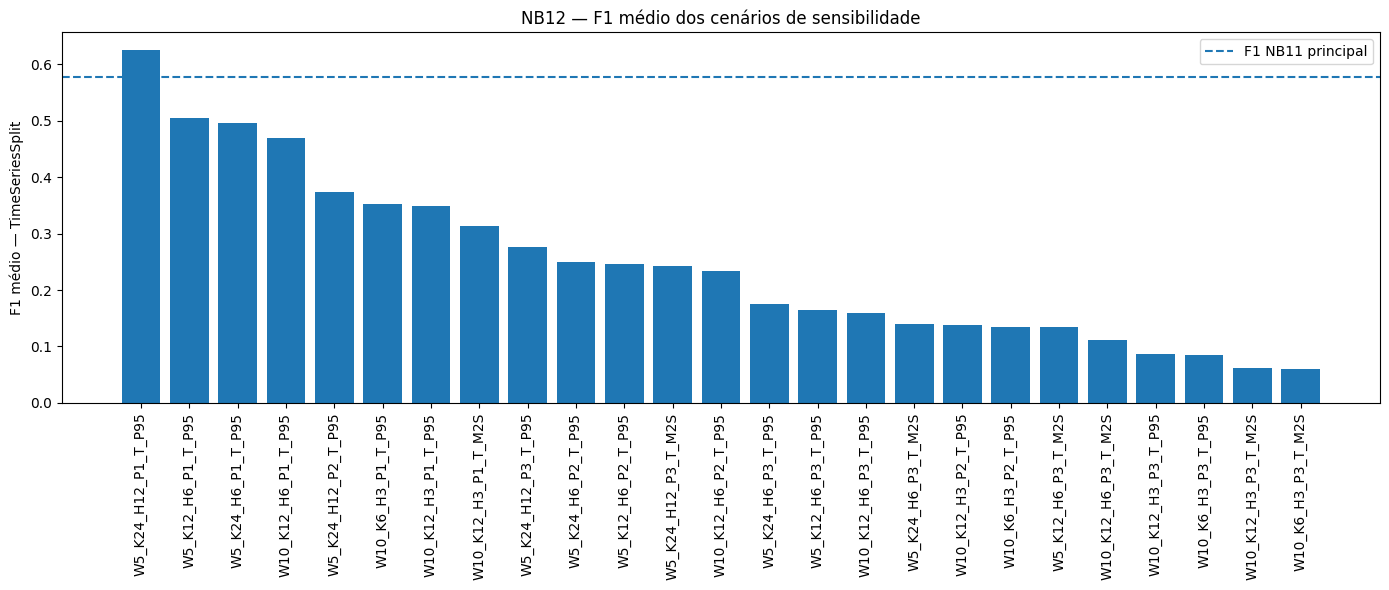

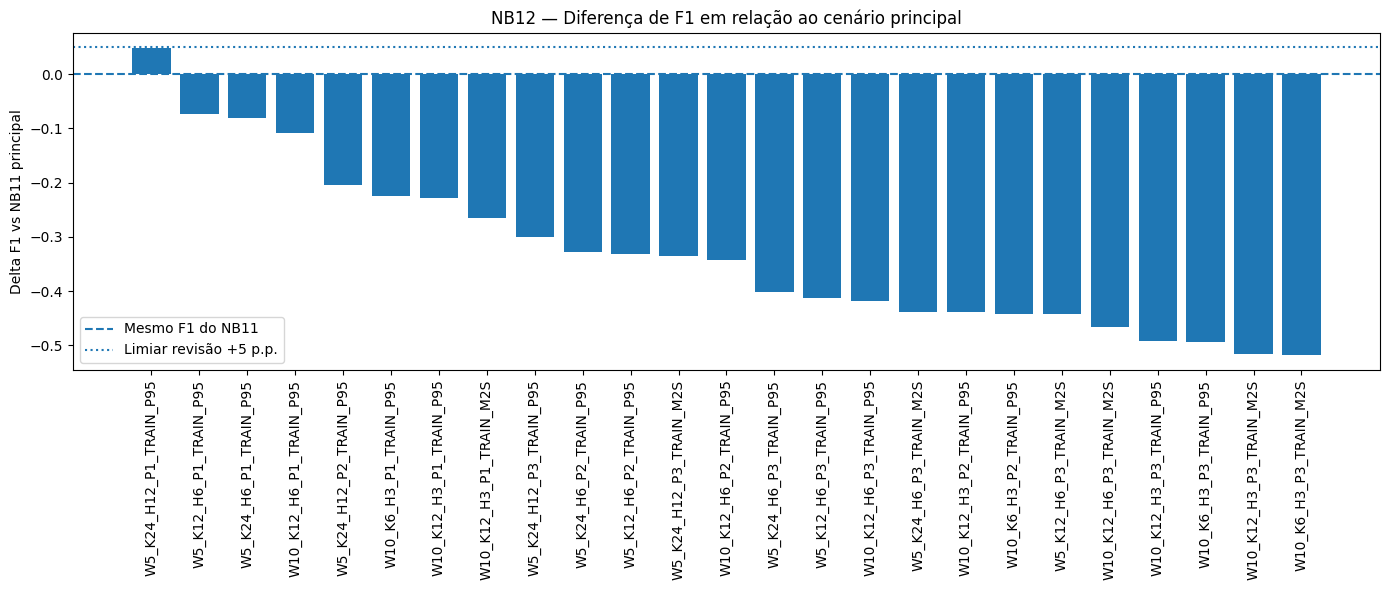

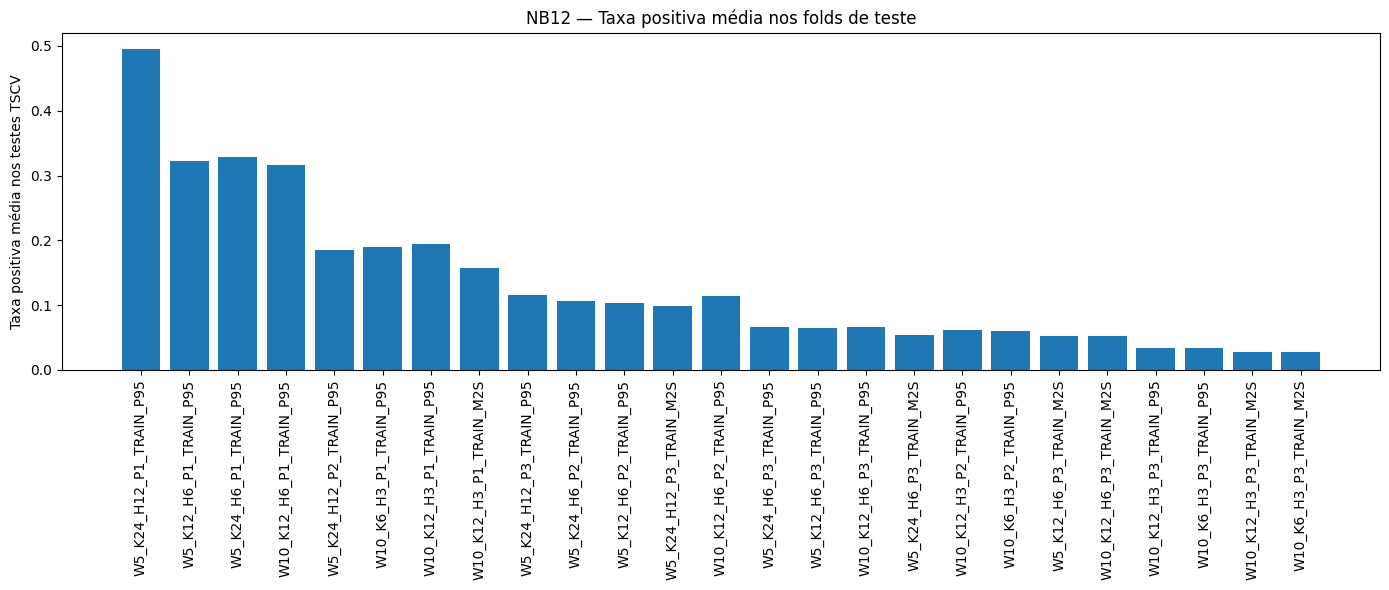

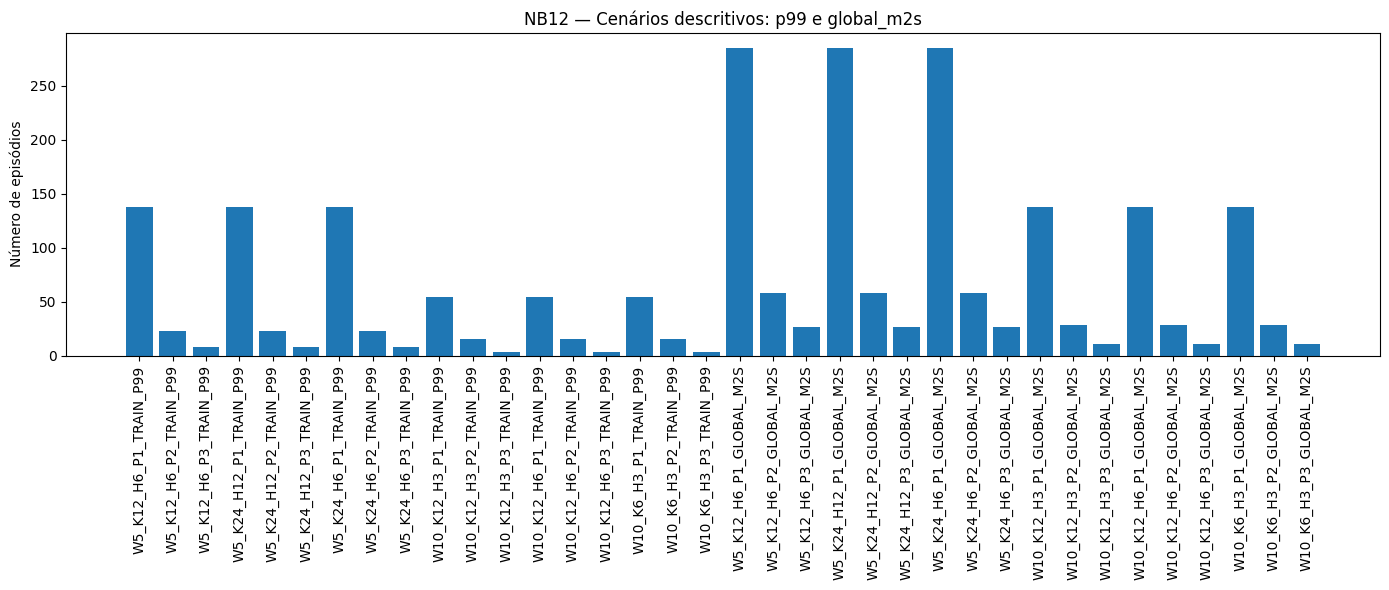


Resumo NB12:
{
  "notebook": "NB12",
  "title": "Sensibilidade Compacta e Robustez das Escolhas",
  "executed_at": "2026-05-24 05:24:46",
  "objective": "Verificar se as decisões centrais do NB10/NB11 permanecem estáveis sob variações moderadas de limiar, persistência e referência histórica.",
  "nb11_reference": {
    "scenario_label": "W5_K24_H12_P1_TRAIN_M2S",
    "model": "logistic_regression",
    "feature_set": "temporal_core",
    "f1_tscv_mean": 0.5773731424098736,
    "features": [
      "fail_rate",
      "n_events",
      "n_failed",
      "n_machines",
      "n_collections",
      "event_FAIL_count",
      "event_LOST_count",
      "lag_1",
      "lag_2",
      "lag_3",
      "rolling_mean_1h",
      "rolling_std_1h",
      "pct_change",
      "zscore_expanding"
    ]
  },
  "scope": {
    "n_sensitivity_only_from_nb10": 25,
    "n_model_candidates": 25,
    "n_model_executed_successfully": 25,
    "n_execution_errors": 0,
    "n_train_p99_descriptive": 18,
    "n_global_m

In [1]:
# ============================================================
# NB12 — Sensibilidade Compacta e Robustez das Escolhas
# Pipeline PPCOMP/DM — Dissertação de Mestrado
#
# Objetivo:
#   Verificar se as decisões centrais do NB10/NB11 permanecem
#   estáveis sob variações moderadas de limiar, persistência e
#   referência histórica.
#
# Princípios:
#   1. Não repetir o NB11.
#   2. Não abrir novo grid search amplo.
#   3. Executar somente o modelo vencedor do NB11.
#   4. Tratar train_p99 apenas como severidade extrema descritiva.
#   5. Manter global_m2s apenas como referência histórica.
#   6. Avaliar a cláusula de revisão train_p95 > train_m2s + 5 p.p.
# ============================================================


# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import re
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS_TSCV = 5
FIXED_TRAIN_FRAC = 0.80
DEFAULT_THRESHOLD = 0.50
REVIEW_DELTA_F1 = 0.05

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB12 iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================
# 1. Paths do projeto
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    BASE_DIR = Path("/content/drive/MyDrive/Mestrado")
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "02-datasets"
FEATURES_DIR = DATA_DIR / "03-features"
MODELS_DIR = BASE_DIR / "03-models"
REPORTS_DIR = BASE_DIR / "04-reports"
NB11_DIR = REPORTS_DIR
NB12_DIR = REPORTS_DIR
NB11_LEGACY_DIR = REPORTS_DIR / "nb11"
NB12_LEGACY_DIR = REPORTS_DIR / "nb12"
FIGURES_DIR = REPORTS_DIR / "figures_nb12"

for p in [FEATURES_DIR, MODELS_DIR, REPORTS_DIR, NB12_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Backup leve dos artefatos anteriores do NB12.
# Os artefatos canônicos novos serão gravados diretamente em 04-reports/.
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")
BACKUP_DIR = REPORTS_DIR / "_backup_previous_artifacts" / RUN_TIMESTAMP_FILE / "nb12"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

def backup_existing_nb12_artifacts():
    import shutil

    patterns = [
        "12_*.csv",
        "12_*.json",
        "12_*.parquet",
        "12_*.txt",
    ]

    copied = []

    for pattern in patterns:
        for path in REPORTS_DIR.glob(pattern):
            if path.is_file():
                target = BACKUP_DIR / path.name
                shutil.copy2(path, target)
                copied.append(str(path))

    if NB12_LEGACY_DIR.exists() and NB12_LEGACY_DIR.is_dir():
        target_dir = BACKUP_DIR / "legacy_nb12"
        if not target_dir.exists():
            shutil.copytree(NB12_LEGACY_DIR, target_dir)
            copied.append(str(NB12_LEGACY_DIR))

    if copied:
        print(f"[BACKUP NB12] Artefatos anteriores copiados para: {BACKUP_DIR}")
    else:
        print("[BACKUP NB12] Nenhum artefato anterior encontrado para backup.")

backup_existing_nb12_artifacts()


print("BASE_DIR    :", BASE_DIR)
print("REPORTS_DIR :", REPORTS_DIR)
print("NB11_DIR    :", NB11_DIR)
print("NB12_DIR    :", NB12_DIR)
print("FIGURES_DIR :", FIGURES_DIR)


# ============================================================
# 2. Utilidades de arquivo
# ============================================================

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def find_file(filename, search_roots, required=True):
    """
    Procura arquivo em locais esperados e, se necessário, recursivamente.
    """
    for root in search_roots:
        candidate = Path(root) / filename
        if candidate.exists():
            return candidate

    for root in search_roots:
        root = Path(root)
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                # Preferir arquivos mais recentes.
                matches = sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)
                return matches[0]

    if required:
        raise FileNotFoundError(f"Arquivo não encontrado: {filename}")

    return None


search_roots = [
    REPORTS_DIR,
    NB11_DIR,
    NB12_DIR,
    BASE_DIR,
]

# Entradas NB10
PATH_DECISIONS = find_file("10_scenario_decisions.csv", search_roots, required=True)
PATH_STATES = find_file("10_scenario_series_states.parquet", search_roots, required=True)
PATH_EPISODES = find_file("10_scenario_episodes.parquet", search_roots, required=True)

PATH_EPISODE_SUMMARY = find_file("10_scenario_episode_summary.csv", search_roots, required=False)
PATH_LABEL_IMPACT = find_file("10_scenario_label_impact.csv", search_roots, required=False)
PATH_THRESHOLDS = find_file("10_scenario_thresholds_summary.csv", search_roots, required=False)
PATH_NB10_JSON = find_file("10_scenario_diagnostics_summary.json", search_roots, required=False)

# Entradas NB11
PATH_WINNER = find_file("11_winner_model.json", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=True)
PATH_NB11_SUMMARY = find_file("11_nb11_summary.json", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=False)
PATH_NB11_METRICS_SUMMARY = find_file("11_metrics_summary.csv", [NB11_DIR, NB11_LEGACY_DIR, REPORTS_DIR, BASE_DIR], required=False)

print("Entradas localizadas:")
print("  10 decisions :", PATH_DECISIONS)
print("  10 states    :", PATH_STATES)
print("  10 episodes  :", PATH_EPISODES)
print("  11 winner    :", PATH_WINNER)


# ============================================================
# 3. Carregamento dos artefatos
# ============================================================

df_decisions = pd.read_csv(PATH_DECISIONS)
df_states_all = pd.read_parquet(PATH_STATES)
df_episodes_all = pd.read_parquet(PATH_EPISODES)

df_episode_summary = pd.read_csv(PATH_EPISODE_SUMMARY) if PATH_EPISODE_SUMMARY else pd.DataFrame()
df_label_impact = pd.read_csv(PATH_LABEL_IMPACT) if PATH_LABEL_IMPACT else pd.DataFrame()
df_thresholds = pd.read_csv(PATH_THRESHOLDS) if PATH_THRESHOLDS else pd.DataFrame()

winner = read_json(PATH_WINNER)
nb11_summary = read_json(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else {}
df_nb11_metrics_summary = pd.read_csv(PATH_NB11_METRICS_SUMMARY) if PATH_NB11_METRICS_SUMMARY else pd.DataFrame()

print("df_decisions:", df_decisions.shape)
print("df_states_all:", df_states_all.shape)
print("df_episodes_all:", df_episodes_all.shape)
print("winner:", winner)


# ============================================================
# 4. Funções de inferência de colunas e parsing de cenário
# ============================================================

def infer_scenario_column(df: pd.DataFrame):
    candidates = [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError("Não foi possível identificar coluna de cenário.")


def infer_category_column(df: pd.DataFrame):
    candidates = [
        "decision",
        "category",
        "decision_category",
        "promotion",
        "status",
        "nb11_decision",
        "action",
    ]

    for c in candidates:
        if c in df.columns:
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance").any():
                return c

    for c in df.columns:
        if df[c].dtype == "object":
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance").any():
                return c

    raise ValueError("Não foi possível identificar coluna de decisão/categoria no NB10.")


def infer_episode_columns(df_episodes: pd.DataFrame):
    start_candidates = [
        "start_bucket_id",
        "episode_start_bucket_id",
        "start_bucket",
        "bucket_start",
        "start",
    ]
    end_candidates = [
        "end_bucket_id",
        "episode_end_bucket_id",
        "end_bucket",
        "bucket_end",
        "end",
    ]

    start_col = next((c for c in start_candidates if c in df_episodes.columns), None)
    end_col = next((c for c in end_candidates if c in df_episodes.columns), None)

    if start_col is None or end_col is None:
        raise ValueError("Colunas de início/fim de episódio não identificadas.")

    return start_col, end_col


scenario_col_decisions = infer_scenario_column(df_decisions)
scenario_col_states = infer_scenario_column(df_states_all)
scenario_col_episodes = infer_scenario_column(df_episodes_all)
decision_col = infer_category_column(df_decisions)
episode_start_col, episode_end_col = infer_episode_columns(df_episodes_all)

print("scenario_col_decisions:", scenario_col_decisions)
print("scenario_col_states   :", scenario_col_states)
print("scenario_col_episodes :", scenario_col_episodes)
print("decision_col          :", decision_col)
print("episode_start_col     :", episode_start_col)
print("episode_end_col       :", episode_end_col)


def parse_scenario_label(label):
    """
    Interpreta labels no padrão:
    W5_K24_H12_P1_TRAIN_M2S
    W5_K24_H12_P1_TRAIN_P95
    W5_K24_H12_P1_GLOBAL_M2S
    etc.
    """
    label = str(label)

    pattern = r"W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_P(?P<P>\d+)_(?P<threshold>.+)"
    m = re.match(pattern, label)

    if not m:
        return {
            "scenario_label": label,
            "W": np.nan,
            "K": np.nan,
            "H": np.nan,
            "P": np.nan,
            "threshold_kind": "unknown",
            "threshold_family": "unknown",
        }

    threshold_kind = m.group("threshold").upper()
    threshold_family = threshold_kind.lower()

    return {
        "scenario_label": label,
        "W": int(m.group("W")),
        "K": int(m.group("K")),
        "H": int(m.group("H")),
        "P": int(m.group("P")),
        "threshold_kind": threshold_kind,
        "threshold_family": threshold_family,
    }


def enrich_with_parsed_scenario(df, scenario_col):
    parsed = df[scenario_col].apply(parse_scenario_label).apply(pd.Series)
    out = df.copy()

    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]

    return out


df_decisions = enrich_with_parsed_scenario(df_decisions, scenario_col_decisions)
df_states_all = enrich_with_parsed_scenario(df_states_all, scenario_col_states)
df_episodes_all = enrich_with_parsed_scenario(df_episodes_all, scenario_col_episodes)

if not df_episode_summary.empty:
    try:
        episode_summary_scen_col = infer_scenario_column(df_episode_summary)
        df_episode_summary = enrich_with_parsed_scenario(df_episode_summary, episode_summary_scen_col)
    except Exception:
        pass

if not df_label_impact.empty:
    try:
        label_impact_scen_col = infer_scenario_column(df_label_impact)
        df_label_impact = enrich_with_parsed_scenario(df_label_impact, label_impact_scen_col)
    except Exception:
        pass


# ============================================================
# 5. Métricas e funções auxiliares
# ============================================================

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_brier(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, np.clip(y_score, 0, 1))


def binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    if len(y_true) == 0:
        return {
            "n": 0,
            "positive_rate": np.nan,
            "threshold": threshold,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "average_precision": np.nan,
            "brier": np.nan,
            "tn": 0,
            "fp": 0,
            "fn": 0,
            "tp": 0,
        }

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "n": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(safe_auc(y_true, y_score)) if not np.isnan(safe_auc(y_true, y_score)) else np.nan,
        "average_precision": float(safe_ap(y_true, y_score)) if not np.isnan(safe_ap(y_true, y_score)) else np.nan,
        "brier": float(safe_brier(y_true, y_score)) if not np.isnan(safe_brier(y_true, y_score)) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def false_alerts_per_day(y_true, y_score, window_minutes, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    false_alerts = int(((y_pred == 1) & (y_true == 0)).sum())
    total_days = (len(y_true) * window_minutes) / (60 * 24)

    return {
        "false_alerts": false_alerts,
        "false_alerts_per_day": float(false_alerts / total_days) if total_days > 0 else np.nan,
    }


# ============================================================
# 6. Features temporais causais
# ============================================================

def add_causal_temporal_features(df: pd.DataFrame, window_minutes: int):
    """
    Reconstrói features temporais causais a partir de fail_rate.
    """
    if "fail_rate" not in df.columns:
        raise ValueError("fail_rate é necessária para criar features temporais causais.")

    df = df.sort_values("bucket_id").copy()

    df["lag_1"] = df["fail_rate"].shift(1)
    df["lag_2"] = df["fail_rate"].shift(2)
    df["lag_3"] = df["fail_rate"].shift(3)

    rolling_window = max(int(round(60 / window_minutes)), 1)

    df["rolling_mean_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )

    df["rolling_std_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=2)
        .std(ddof=0)
    )

    previous = df["fail_rate"].shift(1)
    df["pct_change"] = (df["fail_rate"] - previous) / previous.replace(0, np.nan)

    expanding_mean = df["fail_rate"].shift(1).expanding(min_periods=2).mean()
    expanding_std = df["fail_rate"].shift(1).expanding(min_periods=2).std(ddof=0)

    df["zscore_expanding"] = (
        (df["fail_rate"] - expanding_mean) / expanding_std.replace(0, np.nan)
    )

    temporal_cols = [
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_mean_1h",
        "rolling_std_1h",
        "pct_change",
        "zscore_expanding",
    ]

    df[temporal_cols] = (
        df[temporal_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    return df


# ============================================================
# 7. Alvo supervisionado
# ============================================================

def get_h_windows_from_label(label, fallback=12):
    parsed = parse_scenario_label(label)
    if pd.isna(parsed["H"]):
        return fallback
    return int(parsed["H"])


def get_window_minutes_from_label(label, fallback=5):
    parsed = parse_scenario_label(label)
    if pd.isna(parsed["W"]):
        return fallback
    return int(parsed["W"])


def ensure_target_column(df: pd.DataFrame, scenario_label: str):
    """
    Garante y_nb12.
    Prioriza alvo já existente; caso contrário, reconstrói pela presença futura de DURING.
    """
    df = df.copy()

    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
        "y_nb11",
    ]

    for c in target_candidates:
        if c in df.columns:
            df["y_nb12"] = df[c].astype(int)

            if "state" in df.columns:
                df = df[df["state"].astype(str).isin(["NORMAL", "BEFORE"])].copy()

            for hcol in ["has_complete_horizon", "complete_horizon", "has_complete_horizon_nb11"]:
                if hcol in df.columns:
                    df = df[df[hcol].astype(bool)].copy()

            return df

    if "state" not in df.columns:
        raise ValueError("Nenhum alvo encontrado e coluna state ausente.")

    h_windows = get_h_windows_from_label(scenario_label, fallback=12)

    df = df.sort_values("bucket_id").reset_index(drop=True).copy()
    states = df["state"].astype(str).values
    during = (states == "DURING")

    y = np.zeros(len(df), dtype=int)

    for step in range(1, h_windows + 1):
        shifted = np.zeros(len(df), dtype=bool)
        shifted[:-step] = during[step:]
        y = np.logical_or(y, shifted)

    df["y_nb12"] = y.astype(int)

    df["has_complete_horizon_nb12"] = False
    if len(df) > h_windows:
        df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb12"] = True

    df = df[
        df["state"].astype(str).isin(["NORMAL", "BEFORE"])
        & df["has_complete_horizon_nb12"]
    ].copy()

    return df


# ============================================================
# 8. Modelo vencedor do NB11
# ============================================================

def make_estimator_from_winner(winner_dict):
    model_name = str(winner_dict.get("model", "logistic_regression"))

    if model_name == "logistic_regression":
        return Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    solver="lbfgs",
                )),
            ]
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        )

    raise ValueError(f"Modelo vencedor não suportado no NB12: {model_name}")


def compute_sample_weight_balanced(y):
    y = np.asarray(y).astype(int)
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)

    weights = np.ones(n, dtype=float)

    for cls, cnt in zip(classes, counts):
        weights[y == cls] = n / (len(classes) * cnt)

    return weights


def fit_winner_model(estimator, model_name, X_train, y_train):
    est = clone(estimator)

    if model_name == "hist_gradient_boosting":
        sw = compute_sample_weight_balanced(y_train)
        est.fit(X_train, y_train, sample_weight=sw)
    else:
        est.fit(X_train, y_train)

    return est


def predict_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))

    return estimator.predict(X).astype(float)


winner_model_name = str(winner.get("model", "logistic_regression"))
winner_feature_set = str(winner.get("feature_set", "temporal_core"))
winner_features = list(winner.get("features", []))

if not winner_features:
    raise ValueError("Arquivo 11_winner_model.json não contém lista de features.")

winner_estimator = make_estimator_from_winner(winner)

nb11_main_f1 = float(winner.get("f1_tscv_mean", np.nan))
nb11_main_scenario = str(winner.get("scenario_label"))
nb11_main_parsed = parse_scenario_label(nb11_main_scenario)

print("Modelo vencedor NB11:", winner_model_name)
print("Feature set vencedor:", winner_feature_set)
print("Cenário principal NB11:", nb11_main_scenario)
print("F1 TSCV referência NB11:", nb11_main_f1)
print("Features:", winner_features)


# ============================================================
# 9. Preparação de um cenário
# ============================================================

def prepare_scenario_dataframe(scenario_label):
    df = df_states_all[
        df_states_all[scenario_col_states].astype(str) == str(scenario_label)
    ].copy()

    if df.empty:
        raise ValueError(f"Nenhuma linha encontrada em states para {scenario_label}")

    if "bucket_id" not in df.columns:
        raise ValueError("Coluna bucket_id obrigatória ausente.")

    window_minutes = get_window_minutes_from_label(scenario_label)
    h_windows = get_h_windows_from_label(scenario_label)

    df = df.sort_values("bucket_id").reset_index(drop=True)

    # Reconstrói features temporais para garantir compatibilidade com temporal_core.
    df = add_causal_temporal_features(df, window_minutes=window_minutes)

    # Garante alvo supervisionado.
    df = ensure_target_column(df, scenario_label=scenario_label)

    # Confere features necessárias.
    missing_features = [c for c in winner_features if c not in df.columns]

    if missing_features:
        raise ValueError(
            f"Cenário {scenario_label} sem features necessárias ao vencedor: {missing_features}"
        )

    df[winner_features] = (
        df[winner_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    return df, window_minutes, h_windows


# ============================================================
# 10. Seleção dos cenários do NB12
# ============================================================

df_decisions["decision_normalized"] = df_decisions[decision_col].astype(str).str.lower()
df_decisions["threshold_normalized"] = df_decisions["threshold_family"].astype(str).str.lower()

# Categorias de interesse.
df_sensitivity_only = df_decisions[
    df_decisions["decision_normalized"].str.contains("sensitivity_only", na=False)
].copy()

df_historical_reference = df_decisions[
    df_decisions["decision_normalized"].str.contains("historical_reference", na=False)
].copy()

# Cenários p99: apenas descritivos.
df_p99_candidates = df_decisions[
    df_decisions["threshold_normalized"].str.contains("p99", na=False)
].copy()

# Cenários global_m2s: referência histórica, sem execução do modelo.
df_global_candidates = df_decisions[
    df_decisions["threshold_normalized"].str.contains("global_m2s", na=False)
].copy()

# Elegíveis para modelo:
# sensitivity_only, exceto p99 e global.
df_model_candidates = df_sensitivity_only[
    ~df_sensitivity_only["threshold_normalized"].str.contains("p99", na=False)
    & ~df_sensitivity_only["threshold_normalized"].str.contains("global_m2s", na=False)
].copy()

# Remover duplicatas por cenário.
df_model_candidates = df_model_candidates.drop_duplicates(subset=[scenario_col_decisions])

model_candidate_labels = df_model_candidates[scenario_col_decisions].astype(str).tolist()
p99_labels = df_p99_candidates[scenario_col_decisions].astype(str).drop_duplicates().tolist()
global_labels = df_global_candidates[scenario_col_decisions].astype(str).drop_duplicates().tolist()

print("\nCenários sensitivity_only:", len(df_sensitivity_only))
print("Cenários elegíveis para modelo NB12:", len(model_candidate_labels))
print("Cenários p99 descritivos:", len(p99_labels))
print("Cenários global_m2s referência:", len(global_labels))

display(df_model_candidates[[scenario_col_decisions, decision_col, "W", "K", "H", "P", "threshold_kind"]].head(30))


# ============================================================
# 11. Avaliação do modelo vencedor nos cenários elegíveis
# ============================================================

def evaluate_winner_on_scenario(scenario_label):
    print("\n" + "=" * 90)
    print("Avaliando cenário de sensibilidade:", scenario_label)
    print("=" * 90)

    df, window_minutes, h_windows = prepare_scenario_dataframe(scenario_label)

    y = df["y_nb12"].astype(int).values
    X = df[winner_features].values

    if len(np.unique(y)) < 2:
        raise ValueError(f"Cenário {scenario_label} possui apenas uma classe após filtros.")

    print("Linhas supervisionadas:", len(df))
    print("Taxa positiva:", round(float(y.mean()), 4))
    print("window_minutes:", window_minutes)
    print("h_windows:", h_windows)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS_TSCV)

    tscv_records = []

    for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X[tr_idx], X[te_idx]
        y_train, y_test = y[tr_idx], y[te_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue

        est = fit_winner_model(
            estimator=winner_estimator,
            model_name=winner_model_name,
            X_train=X_train,
            y_train=y_train,
        )

        score_test = predict_score(est, X_test)

        metrics = binary_metrics(y_test, score_test, threshold=DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(
            y_test,
            score_test,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        tscv_records.append({
            "scenario_label": scenario_label,
            "model": winner_model_name,
            "feature_set": winner_feature_set,
            "validation": "timeseries_split",
            "fold": int(fold_id),
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "train_positive_rate": float(y_train.mean()),
            "test_positive_rate": float(y_test.mean()),
            "window_minutes": int(window_minutes),
            "h_windows": int(h_windows),
            "n_features": int(len(winner_features)),
            "features": "|".join(winner_features),
            **parse_scenario_label(scenario_label),
            **metrics,
            **fa,
        })

    # Corte fixo 80/20 complementar.
    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    X_train = df_train[winner_features].values
    y_train = df_train["y_nb12"].astype(int).values

    X_test = df_test[winner_features].values
    y_test = df_test["y_nb12"].astype(int).values

    fixed_records = []
    score_rows = []

    if len(np.unique(y_train)) >= 2 and len(np.unique(y_test)) >= 2:
        est_fixed = fit_winner_model(
            estimator=winner_estimator,
            model_name=winner_model_name,
            X_train=X_train,
            y_train=y_train,
        )

        score_test = predict_score(est_fixed, X_test)

        metrics_fixed = binary_metrics(y_test, score_test, threshold=DEFAULT_THRESHOLD)
        fa_fixed = false_alerts_per_day(
            y_test,
            score_test,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        fixed_records.append({
            "scenario_label": scenario_label,
            "model": winner_model_name,
            "feature_set": winner_feature_set,
            "validation": "fixed_80_20",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "train_positive_rate": float(y_train.mean()),
            "test_positive_rate": float(y_test.mean()),
            "window_minutes": int(window_minutes),
            "h_windows": int(h_windows),
            "n_features": int(len(winner_features)),
            "features": "|".join(winner_features),
            **parse_scenario_label(scenario_label),
            **metrics_fixed,
            **fa_fixed,
        })

        score_df = df_test[["bucket_id"]].copy()
        score_df["scenario_label"] = scenario_label
        score_df["model"] = winner_model_name
        score_df["feature_set"] = winner_feature_set
        score_df["validation"] = "fixed_80_20"
        score_df["y_true"] = y_test
        score_df["score_raw"] = score_test
        score_df["window_minutes"] = int(window_minutes)
        score_df["h_windows"] = int(h_windows)
        score_df["n_features"] = int(len(winner_features))
        score_df["features"] = "|".join(winner_features)

        score_rows.append(score_df)

    df_tscv = pd.DataFrame(tscv_records)
    df_fixed = pd.DataFrame(fixed_records)
    df_scores = pd.concat(score_rows, ignore_index=True) if score_rows else pd.DataFrame()

    return df_tscv, df_fixed, df_scores


all_tscv = []
all_fixed = []
all_scores = []
execution_errors = []

for scenario_label in model_candidate_labels:
    try:
        df_tscv, df_fixed, df_scores = evaluate_winner_on_scenario(scenario_label)

        all_tscv.append(df_tscv)
        all_fixed.append(df_fixed)
        all_scores.append(df_scores)

    except Exception as e:
        print("ERRO no cenário:", scenario_label, "->", str(e))
        execution_errors.append({
            "scenario_label": scenario_label,
            "error": str(e),
        })

df_tscv_all = pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame()
df_fixed_all = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
df_scores_all = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()

print("\nExecução dos cenários de sensibilidade concluída.")
print("df_tscv_all :", df_tscv_all.shape)
print("df_fixed_all:", df_fixed_all.shape)
print("df_scores_all:", df_scores_all.shape)
print("erros:", len(execution_errors))


# ============================================================
# 12. Resumo dos cenários executados
# ============================================================

def summarize_tscv(df_tscv):
    if df_tscv.empty:
        return pd.DataFrame()

    rows = []

    for scenario_label, g in df_tscv.groupby("scenario_label"):
        parsed = parse_scenario_label(scenario_label)

        rows.append({
            "scenario_label": scenario_label,
            **parsed,
            "model": winner_model_name,
            "feature_set": winner_feature_set,
            "n_folds_valid": int(g["fold"].nunique()),
            "n_features": int(g["n_features"].iloc[0]),
            "features": str(g["features"].iloc[0]),

            "n_test_total": int(g["n_test"].sum()),
            "positive_rate_test_mean": float(g["test_positive_rate"].mean()),

            "accuracy_tscv_mean": float(g["accuracy"].mean()),
            "accuracy_tscv_std": float(g["accuracy"].std(ddof=0)),

            "precision_tscv_mean": float(g["precision"].mean()),
            "precision_tscv_std": float(g["precision"].std(ddof=0)),

            "recall_tscv_mean": float(g["recall"].mean()),
            "recall_tscv_std": float(g["recall"].std(ddof=0)),

            "f1_tscv_mean": float(g["f1"].mean()),
            "f1_tscv_std": float(g["f1"].std(ddof=0)),

            "roc_auc_tscv_mean": float(g["roc_auc"].mean()),
            "roc_auc_tscv_std": float(g["roc_auc"].std(ddof=0)),

            "average_precision_tscv_mean": float(g["average_precision"].mean()),
            "average_precision_tscv_std": float(g["average_precision"].std(ddof=0)),

            "brier_tscv_mean": float(g["brier"].mean()),
            "brier_tscv_std": float(g["brier"].std(ddof=0)),

            "false_alerts_per_day_tscv_mean": float(g["false_alerts_per_day"].mean()),
            "false_alerts_per_day_tscv_std": float(g["false_alerts_per_day"].std(ddof=0)),

            "delta_f1_vs_nb11_main": float(g["f1"].mean() - nb11_main_f1),
            "review_threshold_exceeded": bool((g["f1"].mean() - nb11_main_f1) > REVIEW_DELTA_F1),
        })

    return pd.DataFrame(rows)


df_sensitivity_summary = summarize_tscv(df_tscv_all)

if not df_sensitivity_summary.empty:
    df_sensitivity_summary = df_sensitivity_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

display(df_sensitivity_summary.head(20))


# ============================================================
# 13. Descritivo p99 e referências históricas
# ============================================================

def descriptive_from_states_and_episodes(labels, descriptor_type):
    """
    Produz resumo descritivo sem execução de modelo.
    Usado para train_p99 e global_m2s.
    """
    rows = []

    for scenario_label in labels:
        df_s = df_states_all[
            df_states_all[scenario_col_states].astype(str) == str(scenario_label)
        ].copy()

        df_e = df_episodes_all[
            df_episodes_all[scenario_col_episodes].astype(str) == str(scenario_label)
        ].copy()

        if df_s.empty:
            continue

        parsed = parse_scenario_label(scenario_label)

        # Tenta reconstruir alvo supervisionado apenas para descritivo.
        try:
            df_prepared = df_s.sort_values("bucket_id").reset_index(drop=True)
            df_prepared = add_causal_temporal_features(
                df_prepared,
                window_minutes=int(parsed["W"]) if not pd.isna(parsed["W"]) else 5,
            )
            df_prepared = ensure_target_column(df_prepared, scenario_label)
            n_supervised = int(len(df_prepared))
            positive_rate = float(df_prepared["y_nb12"].mean()) if len(df_prepared) else np.nan
            positives = int(df_prepared["y_nb12"].sum()) if len(df_prepared) else 0
            negatives = int(len(df_prepared) - positives) if len(df_prepared) else 0
        except Exception:
            n_supervised = np.nan
            positive_rate = np.nan
            positives = np.nan
            negatives = np.nan

        # Janelas críticas: se houver state DURING, contar; se houver flag, usar flag.
        if "state" in df_s.columns:
            critical_windows = int((df_s["state"].astype(str) == "DURING").sum())
        elif "is_critical" in df_s.columns:
            critical_windows = int(df_s["is_critical"].sum())
        else:
            critical_windows = np.nan

        rows.append({
            "scenario_label": scenario_label,
            **parsed,
            "descriptor_type": descriptor_type,
            "n_windows_total": int(len(df_s)),
            "critical_windows_or_during_windows": critical_windows,
            "n_episodes": int(len(df_e)),
            "n_supervised_rows": n_supervised,
            "positives": positives,
            "negatives": negatives,
            "positive_rate": positive_rate,
            "nb12_policy": (
                "descriptive_only_no_model_execution"
                if descriptor_type == "train_p99_extreme_severity"
                else "historical_reference_no_model_execution"
            ),
        })

    return pd.DataFrame(rows)


df_p99_descriptive = descriptive_from_states_and_episodes(
    p99_labels,
    descriptor_type="train_p99_extreme_severity",
)

df_global_descriptive = descriptive_from_states_and_episodes(
    global_labels,
    descriptor_type="global_m2s_historical_reference",
)

df_descriptive = pd.concat(
    [df_p99_descriptive, df_global_descriptive],
    ignore_index=True,
)

display(df_descriptive.head(30))


# ============================================================
# 14. Cláusula de revisão metodológica — train_p95
# ============================================================

def is_same_temporal_structure_as_main(row):
    """
    Compara W, K, H e P com cenário principal do NB11.
    O limiar pode diferir.
    """
    return (
        int(row["W"]) == int(nb11_main_parsed["W"])
        and int(row["K"]) == int(nb11_main_parsed["K"])
        and int(row["H"]) == int(nb11_main_parsed["H"])
        and int(row["P"]) == int(nb11_main_parsed["P"])
    )


train_p95_summary = pd.DataFrame()

if not df_sensitivity_summary.empty:
    train_p95_summary = df_sensitivity_summary[
        df_sensitivity_summary["threshold_family"]
        .astype(str)
        .str.contains("train_p95", case=False, na=False)
    ].copy()


matched_p95 = pd.DataFrame()

if not train_p95_summary.empty:
    matched_mask = train_p95_summary.apply(is_same_temporal_structure_as_main, axis=1)
    matched_p95 = train_p95_summary[matched_mask].copy()


if not matched_p95.empty:
    selected_p95_row = matched_p95.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    p95_comparison_mode = "same_W_K_H_P_as_nb11_main"

elif not train_p95_summary.empty:
    selected_p95_row = train_p95_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    p95_comparison_mode = "best_available_train_p95_sensitivity"

else:
    selected_p95_row = None
    p95_comparison_mode = "no_train_p95_model_result_available"


if selected_p95_row is not None:
    p95_f1 = float(selected_p95_row["f1_tscv_mean"])
    p95_delta = p95_f1 - nb11_main_f1

    scenario_reassessment_required = bool(p95_delta > REVIEW_DELTA_F1)

    train_p95_review = {
        "nb11_main_scenario": nb11_main_scenario,
        "nb11_main_f1_tscv_mean": nb11_main_f1,
        "comparison_mode": p95_comparison_mode,
        "selected_train_p95_scenario": str(selected_p95_row["scenario_label"]),
        "selected_train_p95_f1_tscv_mean": p95_f1,
        "delta_f1_p95_minus_main": p95_delta,
        "review_delta_threshold": REVIEW_DELTA_F1,
        "scenario_reassessment_required": scenario_reassessment_required,
        "decision": (
            "REAVALIAR cenário principal: train_p95 superou train_m2s por mais de 5 p.p."
            if scenario_reassessment_required
            else "Manter train_m2s como cenário principal; train_p95 permanece como sensibilidade."
        ),
    }

else:
    train_p95_review = {
        "nb11_main_scenario": nb11_main_scenario,
        "nb11_main_f1_tscv_mean": nb11_main_f1,
        "comparison_mode": p95_comparison_mode,
        "selected_train_p95_scenario": None,
        "selected_train_p95_f1_tscv_mean": None,
        "delta_f1_p95_minus_main": None,
        "review_delta_threshold": REVIEW_DELTA_F1,
        "scenario_reassessment_required": False,
        "decision": (
            "Nenhum cenário train_p95 elegível foi executado; "
            "não há acionamento da cláusula de revisão."
        ),
    }


print("\nRevisão train_p95:")
print(json.dumps(train_p95_review, ensure_ascii=False, indent=2))


# ============================================================
# 15. Figuras diagnósticas
# ============================================================

# Figura 1 — F1 dos cenários de sensibilidade.
if not df_sensitivity_summary.empty:
    fig_df = df_sensitivity_summary.copy()
    fig_df["short_label"] = (
        fig_df["scenario_label"]
        .str.replace("_TRAIN_", "_T_", regex=False)
        .str.replace("_GLOBAL_", "_G_", regex=False)
    )

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["f1_tscv_mean"])
    plt.axhline(nb11_main_f1, linestyle="--", label="F1 NB11 principal")
    plt.xticks(range(len(fig_df)), fig_df["short_label"], rotation=90)
    plt.ylabel("F1 médio — TimeSeriesSplit")
    plt.title("NB12 — F1 médio dos cenários de sensibilidade")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig01_f1_sensitivity_tscv.png", dpi=200)
    plt.show()

# Figura 2 — Delta de F1 em relação ao NB11.
if not df_sensitivity_summary.empty:
    fig_df = df_sensitivity_summary.copy()

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["delta_f1_vs_nb11_main"])
    plt.axhline(0.0, linestyle="--", label="Mesmo F1 do NB11")
    plt.axhline(REVIEW_DELTA_F1, linestyle=":", label="Limiar revisão +5 p.p.")
    plt.xticks(range(len(fig_df)), fig_df["scenario_label"], rotation=90)
    plt.ylabel("Delta F1 vs NB11 principal")
    plt.title("NB12 — Diferença de F1 em relação ao cenário principal")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig02_delta_f1_vs_nb11.png", dpi=200)
    plt.show()

# Figura 3 — Taxa positiva dos cenários executados.
if not df_sensitivity_summary.empty:
    fig_df = df_sensitivity_summary.copy()

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["positive_rate_test_mean"])
    plt.xticks(range(len(fig_df)), fig_df["scenario_label"], rotation=90)
    plt.ylabel("Taxa positiva média nos testes TSCV")
    plt.title("NB12 — Taxa positiva média nos folds de teste")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig03_positive_rate_test_tscv.png", dpi=200)
    plt.show()

# Figura 4 — Descritivo p99/global.
if not df_descriptive.empty:
    fig_df = df_descriptive.copy()

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["n_episodes"])
    plt.xticks(range(len(fig_df)), fig_df["scenario_label"], rotation=90)
    plt.ylabel("Número de episódios")
    plt.title("NB12 — Cenários descritivos: p99 e global_m2s")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_fig04_descriptive_episodes_p99_global.png", dpi=200)
    plt.show()


# ============================================================
# 16. Salvamento dos artefatos
# ============================================================

df_tscv_all.to_csv(NB12_DIR / "12_sensitivity_metrics_tscv.csv", index=False)
df_fixed_all.to_csv(NB12_DIR / "12_sensitivity_metrics_fixed_split.csv", index=False)
df_sensitivity_summary.to_csv(NB12_DIR / "12_sensitivity_summary.csv", index=False)
df_descriptive.to_csv(NB12_DIR / "12_sensitivity_descriptive.csv", index=False)

if not df_scores_all.empty:
    df_scores_all.to_parquet(NB12_DIR / "12_scores_sensitivity_fixed.parquet", index=False)

save_json(train_p95_review, NB12_DIR / "12_train_p95_review.json")

if execution_errors:
    pd.DataFrame(execution_errors).to_csv(NB12_DIR / "12_execution_errors.csv", index=False)


# ============================================================
# 17. Sumário final do NB12
# ============================================================

best_sensitivity = None

if not df_sensitivity_summary.empty:
    best_row = df_sensitivity_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    best_sensitivity = {
        "scenario_label": str(best_row["scenario_label"]),
        "threshold_kind": str(best_row["threshold_kind"]),
        "W": int(best_row["W"]) if not pd.isna(best_row["W"]) else None,
        "K": int(best_row["K"]) if not pd.isna(best_row["K"]) else None,
        "H": int(best_row["H"]) if not pd.isna(best_row["H"]) else None,
        "P": int(best_row["P"]) if not pd.isna(best_row["P"]) else None,
        "f1_tscv_mean": float(best_row["f1_tscv_mean"]),
        "f1_tscv_std": float(best_row["f1_tscv_std"]),
        "recall_tscv_mean": float(best_row["recall_tscv_mean"]),
        "precision_tscv_mean": float(best_row["precision_tscv_mean"]),
        "roc_auc_tscv_mean": float(best_row["roc_auc_tscv_mean"]),
        "average_precision_tscv_mean": float(best_row["average_precision_tscv_mean"]),
        "delta_f1_vs_nb11_main": float(best_row["delta_f1_vs_nb11_main"]),
    }

nb12_summary = {
    "notebook": "NB12",
    "title": "Sensibilidade Compacta e Robustez das Escolhas",
    "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "objective": (
        "Verificar se as decisões centrais do NB10/NB11 permanecem estáveis "
        "sob variações moderadas de limiar, persistência e referência histórica."
    ),

    "nb11_reference": {
        "scenario_label": nb11_main_scenario,
        "model": winner_model_name,
        "feature_set": winner_feature_set,
        "f1_tscv_mean": nb11_main_f1,
        "features": winner_features,
    },

    "scope": {
        "n_sensitivity_only_from_nb10": int(len(df_sensitivity_only)),
        "n_model_candidates": int(len(model_candidate_labels)),
        "n_model_executed_successfully": int(df_sensitivity_summary["scenario_label"].nunique()) if not df_sensitivity_summary.empty else 0,
        "n_execution_errors": int(len(execution_errors)),
        "n_train_p99_descriptive": int(len(p99_labels)),
        "n_global_m2s_reference": int(len(global_labels)),
        "model_execution_policy": (
            "Executar somente o modelo vencedor do NB11 nos cenários sensitivity_only elegíveis; "
            "não executar modelo sobre train_p99 nem global_m2s."
        ),
    },

    "validation": {
        "main": "TimeSeriesSplit",
        "n_splits": N_SPLITS_TSCV,
        "complementary": "fixed_80_20",
        "fixed_train_frac": FIXED_TRAIN_FRAC,
        "default_threshold": DEFAULT_THRESHOLD,
    },

    "best_sensitivity_result": best_sensitivity,
    "train_p95_review": train_p95_review,

    "methodological_decision": (
        "Reavaliar cenário principal."
        if train_p95_review.get("scenario_reassessment_required", False)
        else "Manter o cenário principal do NB11; cenários train_p95/P3 permanecem como sensibilidade."
    ),

    "methodological_notes": [
        "O NB12 não repete o NB11 e não reabre grid search amplo.",
        "Apenas o modelo vencedor do NB11 é executado nos cenários de sensibilidade elegíveis.",
        "Cenários train_p99 são tratados apenas de forma descritiva, como severidade extrema.",
        "Cenários global_m2s são tratados como referência histórica, não como candidatos causais principais.",
        "A cláusula de revisão é acionada somente se train_p95 superar o F1 do cenário train_m2s principal por mais de 5 pontos percentuais.",
        "O corte fixo 80/20 permanece complementar; a evidência principal é o TimeSeriesSplit.",
    ],

    "outputs": {
        "sensitivity_metrics_tscv": str(NB12_DIR / "12_sensitivity_metrics_tscv.csv"),
        "sensitivity_metrics_fixed_split": str(NB12_DIR / "12_sensitivity_metrics_fixed_split.csv"),
        "sensitivity_summary": str(NB12_DIR / "12_sensitivity_summary.csv"),
        "sensitivity_descriptive": str(NB12_DIR / "12_sensitivity_descriptive.csv"),
        "train_p95_review": str(NB12_DIR / "12_train_p95_review.json"),
        "scores_sensitivity_fixed": str(NB12_DIR / "12_scores_sensitivity_fixed.parquet"),
        "execution_errors": str(NB12_DIR / "12_execution_errors.csv") if execution_errors else None,
    },

    "figures": {
        "f1_sensitivity_tscv": str(FIGURES_DIR / "12_fig01_f1_sensitivity_tscv.png"),
        "delta_f1_vs_nb11": str(FIGURES_DIR / "12_fig02_delta_f1_vs_nb11.png"),
        "positive_rate_test_tscv": str(FIGURES_DIR / "12_fig03_positive_rate_test_tscv.png"),
        "descriptive_episodes_p99_global": str(FIGURES_DIR / "12_fig04_descriptive_episodes_p99_global.png"),
    },
}

save_json(nb12_summary, NB12_DIR / "12_nb12_summary.json")

print("\nResumo NB12:")
print(json.dumps(nb12_summary, ensure_ascii=False, indent=2))

print("\nArtefatos salvos em:", NB12_DIR)
print("Figuras salvas em:", FIGURES_DIR)
print("NB12 finalizado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

## 16. Achados Experimentais da Execução

### 16.1 Síntese da execução

O NB12 foi executado com sucesso como etapa de sensibilidade compacta e robustez das escolhas consolidadas nos notebooks NB10 e NB11.

O objetivo do notebook não foi reabrir uma nova busca ampla de modelos, limiares ou cenários. Seu papel foi verificar se a decisão central do pipeline — manter o cenário `W5_K24_H12_P1_TRAIN_M2S`, com modelo `logistic_regression` e conjunto de features `temporal_core` — permanece defensável diante de variações moderadas de limiar, persistência mínima e referência histórica.

A execução utilizou como referência o vencedor do NB11:

| Item | Valor |
|---|---|
| Cenário principal | `W5_K24_H12_P1_TRAIN_M2S` |
| Modelo | `logistic_regression` |
| Feature set | `temporal_core` |
| F1 médio TSCV de referência | 0,5774 |
| Número de features | 14 |

As features herdadas do NB11 foram:

```text
fail_rate
n_events
n_failed
n_machines
n_collections
event_FAIL_count
event_LOST_count
lag_1
lag_2
lag_3
rolling_mean_1h
rolling_std_1h
pct_change
zscore_expanding
```

A execução do NB12 foi concluída sem erros de execução nos cenários elegíveis para modelagem.

### 16.2 Parâmetros principais da execução

Os principais parâmetros da execução foram:

| Parâmetro | Valor | Interpretação |
|---|---:|---|
| Cenários `sensitivity_only` recebidos do NB10 | 25 | Cenários elegíveis para execução do modelo vencedor |
| Candidatos a execução de modelo | 25 | Cenários de sensibilidade efetivamente testados |
| Execuções bem-sucedidas | 25 | Nenhuma falha de execução registrada |
| Erros de execução | 0 | Não houve erro de modelagem |
| Cenários `train_p99` descritivos | 18 | Tratados apenas como severidade extrema |
| Cenários `global_m2s` descritivos | 18 | Tratados apenas como referência histórica |
| Validação principal | `TimeSeriesSplit` | Evidência principal |
| Número de folds | 5 | Partições temporais progressivas |
| Validação complementar | `fixed_80_20` | Inspeção complementar |
| Fração de treino no corte fixo | 0,80 | Corte temporal fixo |
| Limiar de classificação | 0,50 | Limiar inicial de decisão |
| Delta de revisão do `train_p95` | 0,05 | Ganho mínimo para reabrir decisão do cenário principal |

A política de execução foi restrita: somente o modelo vencedor do NB11 foi executado nos cenários `sensitivity_only` elegíveis. Cenários `train_p99` e `global_m2s` não foram usados para treinar ou avaliar modelo como candidatos principais.

## 17. Escopo Executado

O NB12 executou três blocos complementares:

1. execução do modelo vencedor do NB11 nos cenários `sensitivity_only`;
2. revisão específica dos cenários `train_p95`;
3. descrição dos cenários `train_p99` e `global_m2s` sem execução de modelo.

O objetivo dessa separação foi evitar que o NB12 se transformasse em novo grid search amplo. O notebook preservou seu papel de diagnóstico de robustez das decisões já tomadas, e não de substituição do NB10 ou do NB11.

O resumo da execução foi:

| Bloco | Quantidade | Tratamento |
|---|---:|---|
| Cenários `sensitivity_only` executados | 25 | Modelo vencedor do NB11 |
| Cenários `train_p99` | 18 | Apenas descritivo |
| Cenários `global_m2s` | 18 | Apenas referência histórica |

Essa delimitação é metodologicamente adequada porque mantém o cenário principal definido pelo NB11 como referência e usa o NB12 apenas para testar se alguma variação moderada justifica revisão.

## 18. Modelo e Features Utilizados

O NB12 utilizou exclusivamente o modelo vencedor do NB11:

| Item | Valor |
|---|---|
| Modelo | `logistic_regression` |
| Feature set | `temporal_core` |
| Número de features | 14 |
| Protocolo principal | `TimeSeriesSplit` |
| Interpretação dos escores | Escore relativo de risco |

A decisão de não testar novamente múltiplos modelos é coerente com o escopo do NB12. O notebook mede sensibilidade da decisão central sob variações de cenário, e não busca novo vencedor por arquitetura ou família de modelo.

## 19. Cenários de Sensibilidade Avaliados

Foram avaliados 25 cenários de sensibilidade com execução do modelo vencedor. Esses cenários incluem variações de:

- granularidade temporal (`W`);
- tamanho das regiões BEFORE/AFTER (`K`);
- horizonte de predição (`H`);
- persistência mínima (`P`);
- limiar causal, especialmente `TRAIN_P95` e variações associadas.

A execução foi bem-sucedida em todos os 25 cenários candidatos. Isso indica que os artefatos herdados do NB10 e do NB11 estão coerentes para suportar avaliação compacta de sensibilidade.

## 20. Resultado Principal da Sensibilidade

O melhor resultado de sensibilidade no `TimeSeriesSplit` foi:

| Métrica | Valor |
|---|---:|
| Cenário | `W5_K24_H12_P1_TRAIN_P95` |
| Tipo de limiar | `TRAIN_P95` |
| W | 5 |
| K | 24 |
| H | 12 |
| P | 1 |
| F1 médio TSCV | 0,6254 |
| Desvio-padrão F1 TSCV | 0,2251 |
| Recall médio TSCV | 0,8727 |
| Precisão média TSCV | 0,5395 |
| ROC-AUC médio TSCV | 0,6539 |
| Average Precision médio TSCV | 0,6151 |
| Delta F1 contra NB11 | +0,0480 |

Esse cenário apresentou resultado numericamente superior ao cenário principal do NB11, com ganho de aproximadamente 4,8 pontos percentuais em F1 médio.

Entretanto, esse ganho não ultrapassou o limiar de revisão definido no NB12, que exige ganho superior a 5 pontos percentuais para reabrir a decisão do cenário principal.

## 21. Cláusula de Revisão Metodológica

A cláusula de revisão metodológica foi definida para impedir troca precipitada do cenário principal por pequenas variações de desempenho.

A regra aplicada foi:

```text
reavaliar cenário principal somente se:
F1_TRAIN_P95 - F1_TRAIN_M2S > 0,05
```

A comparação específica foi:

| Item | Valor |
|---|---:|
| Cenário principal NB11 | `W5_K24_H12_P1_TRAIN_M2S` |
| F1 médio NB11 | 0,5774 |
| Cenário `train_p95` comparável | `W5_K24_H12_P1_TRAIN_P95` |
| F1 médio `train_p95` | 0,6254 |
| Delta observado | +0,0480 |
| Limiar de revisão | 0,0500 |
| Revisão obrigatória? | Não |

Como o ganho observado ficou abaixo do limiar de revisão, a decisão metodológica foi manter `train_m2s` como cenário principal e tratar `train_p95` como sensibilidade relevante.

## 22. Interpretação do `train_p95`

O cenário `W5_K24_H12_P1_TRAIN_P95` apresentou o melhor desempenho entre os cenários de sensibilidade. Esse resultado mostra que o limiar `train_p95` é competitivo e merece ser mencionado na dissertação.

Contudo, o ganho observado foi marginalmente inferior ao critério previamente definido para reabrir a escolha principal. Além disso, o `train_m2s` já havia sido selecionado por sua coerência com a formulação causal do NB10 e por sua função como cenário central do pipeline.

Assim, o resultado do `train_p95` deve ser interpretado como evidência de robustez e não como substituição automática do cenário principal.

A conclusão correta é:

```text
Manter train_m2s como cenário principal; train_p95 permanece como sensibilidade.
```

## 23. Interpretação dos Cenários P3

Os cenários com persistência mínima `P3` foram avaliados quando classificados como `sensitivity_only`. Em geral, eles apresentaram menor taxa positiva, maior desbalanceamento e redução do F1 médio em relação aos cenários com persistência menor.

Esse comportamento é esperado, pois persistência maior torna a definição de criticidade mais restritiva. Isso reduz a quantidade de exemplos positivos e tende a aumentar a dificuldade da tarefa supervisionada.

A leitura metodológica é que os cenários `P3` são úteis como sensibilidade conservadora, mas não devem substituir o cenário principal da dissertação.

## 24. Folds Válidos no TimeSeriesSplit

Embora o protocolo principal tenha usado `TimeSeriesSplit` com 5 folds, nem todos os cenários produziram 5 folds válidos para agregação. Alguns cenários, especialmente os mais restritivos, apresentaram folds com baixa ocorrência ou ausência de classe positiva, reduzindo o número de folds utilizáveis.

A distribuição observada foi:

| Folds válidos | Número de cenários |
|---:|---:|
| 2 | 12 |
| 4 | 6 |
| 5 | 7 |

Esse achado é importante porque reforça a sensibilidade da tarefa à definição de cenário e ao desbalanceamento temporal. Cenários com menos folds válidos devem ser interpretados com maior cautela, mesmo quando apresentarem métricas aparentemente interessantes.

## 25. Cenários `train_p99`

Os cenários `train_p99` foram tratados apenas de forma descritiva, como representação de severidade extrema. Foram analisados 18 cenários nessa categoria.

Essa decisão é adequada porque `train_p99` tende a capturar apenas situações muito raras e severas, reduzindo drasticamente a densidade de exemplos positivos. Usá-los como candidatos principais de modelagem poderia produzir conclusões instáveis ou pouco representativas.

Assim, os cenários `train_p99` devem ser preservados como análise descritiva de severidade extrema, e não como alternativa principal de pipeline.

## 26. Cenários `global_m2s`

Os cenários `global_m2s` foram tratados como referência histórica, também sem execução de modelo como candidatos principais. Foram analisados 18 cenários nessa categoria.

Essa decisão é coerente com o refinamento metodológico iniciado no NB10, pois o uso de limiar global retrospectivo pode incorporar informação do período de teste. O `global_m2s` permanece útil para comparação histórica com fases anteriores do projeto, mas não deve orientar a decisão principal da dissertação.

## 27. Comparação com o Cenário Principal do NB11

A comparação central do NB12 foi entre:

| Item | Cenário | F1 médio TSCV |
|---|---|---:|
| Referência principal NB11 | `W5_K24_H12_P1_TRAIN_M2S` | 0,5774 |
| Melhor sensibilidade | `W5_K24_H12_P1_TRAIN_P95` | 0,6254 |

O ganho absoluto da melhor sensibilidade foi de aproximadamente 0,0480. Esse valor é relevante, mas não suficiente para acionar a cláusula de revisão de 0,05.

Portanto, o NB12 não invalida a escolha principal do NB11. Ao contrário, mostra que existe uma alternativa próxima e competitiva, mas que a decisão central permanece defensável pelo critério previamente estabelecido.

## 28. Interpretação Metodológica dos Resultados

A execução do NB12 produz cinco achados centrais.

Primeiro, a escolha principal do NB11 permanece defensável. Nenhum cenário de sensibilidade ultrapassou o limiar de revisão metodológica definido para substituir o cenário principal.

Segundo, o `train_p95` é uma sensibilidade forte. O cenário `W5_K24_H12_P1_TRAIN_P95` obteve F1 médio superior ao cenário principal, mas por margem insuficiente para reabrir a decisão central.

Terceiro, cenários com maior persistência, especialmente `P3`, tendem a reduzir a densidade de positivos e a estabilidade da avaliação.

Quarto, `train_p99` deve permanecer como severidade extrema descritiva, não como candidato principal de modelagem.

Quinto, `global_m2s` deve permanecer como referência histórica, não como alternativa causal principal.

Esses achados reforçam que o pipeline não depende de uma única escolha arbitrária. As decisões centrais permanecem estáveis sob variações moderadas, desde que os critérios de revisão sejam aplicados de forma prévia e consistente.

## 29. Artefatos Gerados

A execução gerou os seguintes artefatos principais:

| Artefato | Finalidade |
|---|---|
| `12_sensitivity_metrics_tscv.csv` | Métricas detalhadas dos cenários de sensibilidade no `TimeSeriesSplit` |
| `12_sensitivity_metrics_fixed_split.csv` | Métricas complementares no corte fixo 80/20 |
| `12_sensitivity_summary.csv` | Consolidação por cenário de sensibilidade |
| `12_sensitivity_descriptive.csv` | Estatísticas descritivas de cenários `train_p99` e `global_m2s` |
| `12_train_p95_review.json` | Revisão específica da cláusula `train_p95` |
| `12_scores_sensitivity_fixed.parquet` | Escores do corte fixo para inspeções complementares |
| `12_nb12_summary.json` | Sumário consolidado do NB12 |

Também foram previstas figuras diagnósticas relacionadas a:

| Figura | Conteúdo |
|---|---|
| `12_fig01_f1_sensitivity_tscv.png` | F1 médio dos cenários de sensibilidade no TSCV |
| `12_fig02_delta_f1_vs_nb11.png` | Delta de F1 em relação ao cenário principal do NB11 |
| `12_fig03_positive_rate_test_tscv.png` | Taxa positiva média nos testes do TSCV |
| `12_fig04_descriptive_episodes_p99_global.png` | Comparação descritiva de episódios em `train_p99` e `global_m2s` |

Os artefatos tabulares e JSON enviados estão coerentes entre si. As figuras foram declaradas no sumário em `04-reports/figures_nb12/`.

## 30. Pontos de Atenção para a Dissertação

A execução do NB12 gera pontos importantes para a redação da dissertação.

Primeiro, a decisão de manter `train_m2s` como cenário principal não é uma escolha isolada. Ela foi confrontada com cenários `train_p95`, persistência adicional, `train_p99` e referência histórica `global_m2s`.

Segundo, o resultado do `train_p95` deve ser relatado com transparência. Ele foi superior ao cenário principal em F1 médio, mas não superou o limiar de revisão definido previamente.

Terceiro, o critério de revisão de 5 pontos percentuais é útil para evitar troca oportunista de cenário por pequena melhora empírica. Isso fortalece a argumentação metodológica da dissertação.

Quarto, cenários `train_p99` e `global_m2s` devem ser descritos como análises auxiliares, não como alternativas equivalentes ao cenário principal.

Quinto, a existência de cenários com apenas 2 ou 4 folds válidos deve ser mencionada como sinal de instabilidade em configurações mais restritivas ou mais desbalanceadas.

Sexto, o NB12 reforça que o pipeline é robusto o suficiente para avançar ao NB13 e NB14 sem reabrir o desenho central do cenário principal.

## 31. Encaminhamento para os Próximos Notebooks

O NB13 deve utilizar os artefatos materializados pelo NB11, especialmente:

```text
11_sequence_input_features.parquet
11_feature_sets.json
11_nb11_summary.json
11_winner_model.json
```

O objetivo do NB13 será avaliar a LSTM como experimento complementar defensivo, usando os mesmos conjuntos de features definidos pelo NB11, especialmente `raw_7` e `temporal_core`.

A decisão do NB12 não exige alteração do cenário principal do pipeline. Portanto, o NB14 deve continuar partindo da referência do NB11, salvo se o NB13 demonstrar ganho relevante da LSTM conforme o gatilho previamente definido.

O NB14 deverá utilizar os escores do modelo de referência para análise de limiar, custo relativo e classes de decisão, preservando a interpretação dos escores como risco relativo temporal.

O NB15 deverá consolidar as visualizações finais a partir da decisão estabilizada em NB11, NB12, NB13 e NB14.

O NB16 deverá consolidar inventário, rastreabilidade, limitações finais e síntese narrativa para a dissertação.

## 32. Conclusão da Etapa

O NB12 cumpriu seu papel no pipeline dissertativo.

A execução confirmou que:

1. o modelo vencedor do NB11 pode ser aplicado com sucesso aos cenários de sensibilidade elegíveis;
2. o cenário `W5_K24_H12_P1_TRAIN_P95` foi a melhor sensibilidade, com F1 médio TSCV de 0,6254;
3. o ganho do `train_p95` sobre o cenário principal foi de 0,0480, abaixo do limiar de revisão de 0,05;
4. a decisão central permanece: manter `train_m2s` como cenário principal;
5. `train_p95` deve permanecer como sensibilidade relevante;
6. cenários `train_p99` devem permanecer como severidade extrema descritiva;
7. cenários `global_m2s` devem permanecer como referência histórica;
8. cenários mais restritivos, especialmente com `P3`, tendem a apresentar menos folds válidos e maior instabilidade;
9. o NB12 não reabre o grid search, mas confirma a robustez metodológica das escolhas centrais.

Assim, o NB12 pode ser considerado tecnicamente fechado. Para a sequência da dissertação, recomenda-se avançar para o NB13 mantendo o cenário principal do NB11 como referência, com `train_p95` documentado como sensibilidade forte, porém insuficiente para substituir a escolha central.
